# Exercício Prático

Você está recebendo o dataset Breast Cancer Wisconsin (Diagnostic), que contém 569 observações provenientes de exames médicos, 30 features (variáveis explicativas) e uma variável-alvo, denominada Diagnosis.

**Descrição da variável-alvo (Diagnosis)**

Indica o tipo de tumor:

M → Maligno (canceroso)

B → Benigno (não canceroso)

**Plano de Trabalho** – Classificação com Regressão Logística
Objetivo

Construir um modelo de Regressão Logística capaz de predizer o tipo de tumor (benigno ou maligno) a partir das features do dataset, simulando um cenário próximo ao de produção.

**Etapa 1 – Carregamento do dataset**

Importar o conjunto de dados.

Verificar dimensões (linhas e colunas).

Conferir tipos das variáveis.

Confirmar ausência de valores ausentes (missing values).

**Etapa 2 – Tratamento e limpeza dos dados**

Remover variáveis não informativas (ex.: identificadores, caso existam).

Converter a variável-alvo Diagnosis em formato numérico:

M → 1

B → 0

Garantir que todas as features estejam em formato numérico contínuo.

**Etapa 3 – Análise exploratória e seleção de variáveis**

Analisar estatísticas descritivas das features.

Avaliar correlação entre as variáveis explicativas.

Identificar possíveis variáveis altamente correlacionadas.

Selecionar as features mais relevantes para o treinamento do modelo, utilizando:

Análise de correlação;

Importância das variáveis;

Ou critérios estatísticos simples (ex.: variância).

**Etapa 4 – Padronização das variáveis**

Aplicar padronização (StandardScaler) nas features, uma vez que a Regressão Logística é sensível à escala dos dados.

**Etapa 5 – Divisão do dataset**

Separar o conjunto de dados da seguinte forma:

95% dos dados → Treinamento e validação do modelo;

5% dos dados → Conjunto de teste final, simulando o modelo em ambiente de produção.

Garantir que a divisão preserve a proporção das classes (stratified split).

**Etapa 6 – Treinamento do modelo**

Ajustar um modelo de Regressão Logística utilizando o conjunto de treinamento.

Definir parâmetros adequados (ex.: regularização).


**Etapa 7 – Avaliação do modelo**

Avaliar o desempenho do classificador por meio de:

Acurácia;

Matriz de confusão;

Sensibilidade (recall);

Especificidade;

Curva ROC e AUC (opcional).

📌 **Tarefa:**
Com base no contexto do problema, explique qual métrica é mais adequada para avaliar o modelo de Regressão Logística e justifique sua escolha, considerando o impacto dos diferentes tipos de erro na classificação dos tumores.

**Etapa 8 – Simulação em produção**

Aplicar o modelo treinado sobre os 5% reservados do dataset.

Comparar as previsões com os valores reais da variável-alvo.

Analisar o desempenho do modelo em dados “não vistos”.

**Etapa 9 – Conclusão**

Interpretar os resultados obtidos.

Discutir a eficácia da Regressão Logística para o problema proposto.

Indicar possíveis melhorias (seleção de variáveis, ajuste de parâmetros, outros classificadores).

Link do Dataset/Documentação: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

## Etapa 1 - Carregamento do dataset

Importar o conjunto de dados.

Verificar dimensões (linhas e colunas).

> 569 linhas por 32 colunas (30 features + 1 classificação + 1 id)

Conferir tipos das variáveis.

> visível no display abaixo

Confirmar ausência de valores ausentes (missing values).

> o display indica que não faltam valores


In [21]:
from pprint import pprint
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

df = fetch_ucirepo(id=17)

X_total = df.data.features
y_total = df.data.targets

X, X_prod, y, y_prod = train_test_split(X_total, y_total, test_size=0.05, random_state=42)

pprint(df.metadata)
display(df.variables)

{'abstract': 'Diagnostic Wisconsin Breast Cancer Database.',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'Features are computed from a digitized image '
                                'of a fine needle aspirate (FNA) of a breast '
                                'mass.  They describe characteristics of the '
                                'cell nuclei present in the image. A few of '
                                'the images can be found at '
                                'http://www.cs.wisc.edu/~street/images/\r\n'
                                '\r\n'
                                'Separating plane described above was obtained '
                                'using Mul

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


In [22]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
radius1,540.0,14.103774,3.512261,7.691000,11.687500,13.335000,15.757500,28.11000
texture1,540.0,19.296370,4.287533,9.710000,16.202500,18.850000,21.785000,39.28000
perimeter1,540.0,91.802093,24.194781,47.920000,75.022500,86.140000,103.725000,188.50000
area1,540.0,652.800926,351.760341,170.400000,419.525000,548.750000,781.400000,2501.00000
smoothness1,540.0,0.096213,0.014030,0.052630,0.086038,0.095720,0.105100,0.16340
compactness1,540.0,0.104039,0.052706,0.019380,0.064815,0.092350,0.130425,0.34540
concavity1,540.0,0.088511,0.079255,0.000000,0.029635,0.060705,0.131000,0.42680
concave_points1,540.0,0.048504,0.038216,0.000000,0.020310,0.033600,0.073460,0.20120
symmetry1,540.0,0.181038,0.027673,0.106000,0.161800,0.179000,0.196250,0.30400
fractal_dimension1,540.0,0.062815,0.007107,0.049960,0.057697,0.061475,0.066128,0.09744


In [23]:
y.value_counts()

Diagnosis
B            339
M            201
Name: count, dtype: int64

## Etapa 2 – Tratamento e limpeza dos dados

Remover variáveis não informativas (ex.: identificadores, caso existam).

> não vieram nas features

Converter a variável-alvo Diagnosis em formato numérico:

- M → 1
- B → 0

> foi gerado `y_num` para essa conversão

Garantir que todas as features estejam em formato numérico contínuo.

> as features já estão no formato

In [ ]:
y_num = y.Diagnosis.map(lambda diagnostico: 1 if diagnostico == 'M' else 0)
y_num.value_counts()

Diagnosis
0    339
1    201
Name: count, dtype: int64

## Etapa 3 – Análise exploratória e seleção de variáveis

Analisar estatísticas descritivas das features.

Avaliar correlação entre as variáveis explicativas.

> maiores correlações observadas em: concave_points1, radius3, perimeter3, concave_points3

Identificar possíveis variáveis altamente correlacionadas.

Selecionar as features mais relevantes para o treinamento do modelo, utilizando:

Análise de correlação;

Importância das variáveis;

Ou critérios estatísticos simples (ex.: variância).

In [64]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

selecter = SelectKBest(score_func=f_classif, k=4).fit(X, y_num)
selecter.get_feature_names_out()

array(['concave_points1', 'radius3', 'perimeter3', 'concave_points3'],
      dtype=object)

In [63]:
selecter2 = SelectKBest(score_func=mutual_info_classif, k=5).fit(X, y_num)
selecter2.get_feature_names_out()

array(['concave_points1', 'radius3', 'perimeter3', 'area3',
       'concave_points3'], dtype=object)

In [25]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
radius1,540.0,14.103774,3.512261,7.691000,11.687500,13.335000,15.757500,28.11000
texture1,540.0,19.296370,4.287533,9.710000,16.202500,18.850000,21.785000,39.28000
perimeter1,540.0,91.802093,24.194781,47.920000,75.022500,86.140000,103.725000,188.50000
area1,540.0,652.800926,351.760341,170.400000,419.525000,548.750000,781.400000,2501.00000
smoothness1,540.0,0.096213,0.014030,0.052630,0.086038,0.095720,0.105100,0.16340
compactness1,540.0,0.104039,0.052706,0.019380,0.064815,0.092350,0.130425,0.34540
concavity1,540.0,0.088511,0.079255,0.000000,0.029635,0.060705,0.131000,0.42680
concave_points1,540.0,0.048504,0.038216,0.000000,0.020310,0.033600,0.073460,0.20120
symmetry1,540.0,0.181038,0.027673,0.106000,0.161800,0.179000,0.196250,0.30400
fractal_dimension1,540.0,0.062815,0.007107,0.049960,0.057697,0.061475,0.066128,0.09744


In [ ]:
# Identificar possíveis variáveis altamente correlacionadas.
X.corrwith(y_num).to_frame('corr').style.background_gradient()

,corr
radius1,0.725548
texture1,0.419171
perimeter1,0.738390
area1,0.702857
smoothness1,0.356725
compactness1,0.592554
concavity1,0.692762
concave_points1,0.775709
symmetry1,0.336167
fractal_dimension1,-0.016445


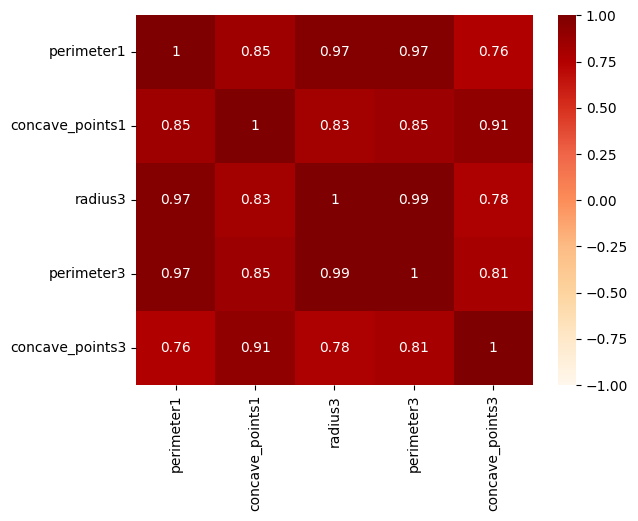

In [58]:
import seaborn as sns
from matplotlib import pyplot as plt

# selecionando colunas com correlação > 75%
colunas_alta_correlacao = ['concave_points1', 'radius3', 'perimeter3', 'concave_points3']
sns.heatmap(
    data=X[selecter.get_feature_names_out()].corr(),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap='OrRd',
)
plt.show()

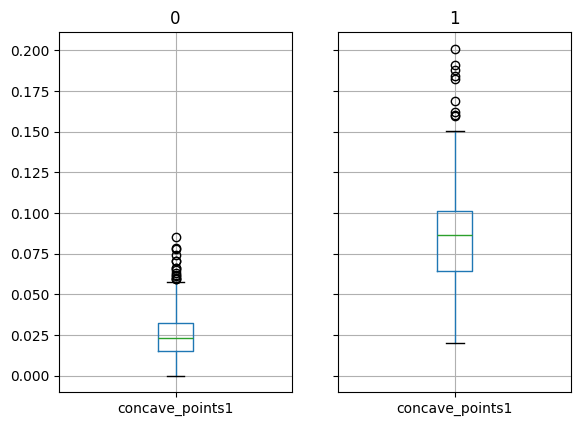

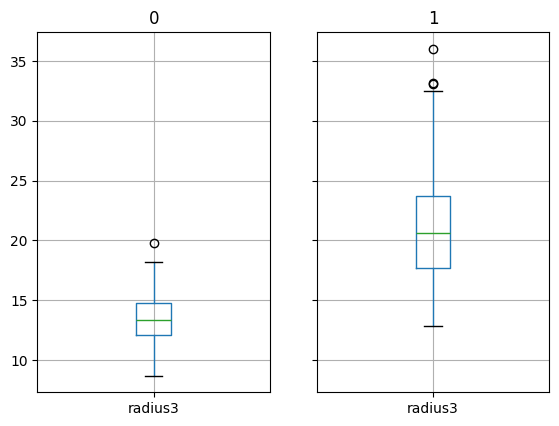

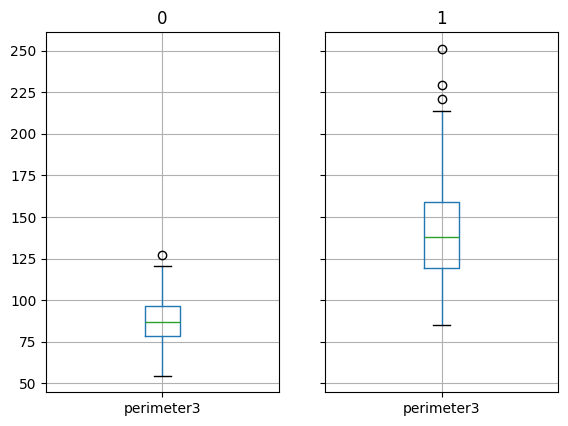

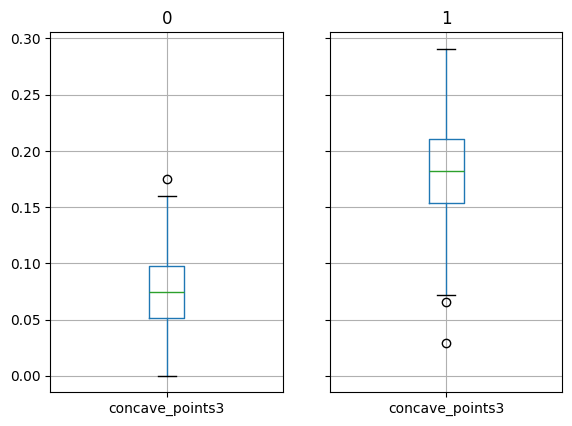

In [54]:
for col in colunas_alta_correlacao:
    X[[col]].groupby(by=y_num).boxplot()
    plt.show()